# Task 5 — Transformer in Action

### PyTorch Implementation of Transformer Components from Scratch
We implement each component of the Transformer architecture in PyTorch from scratch (without utilizing PyTorch's pre-packaged layer wrappers) to trace the exact tensor dimensions.

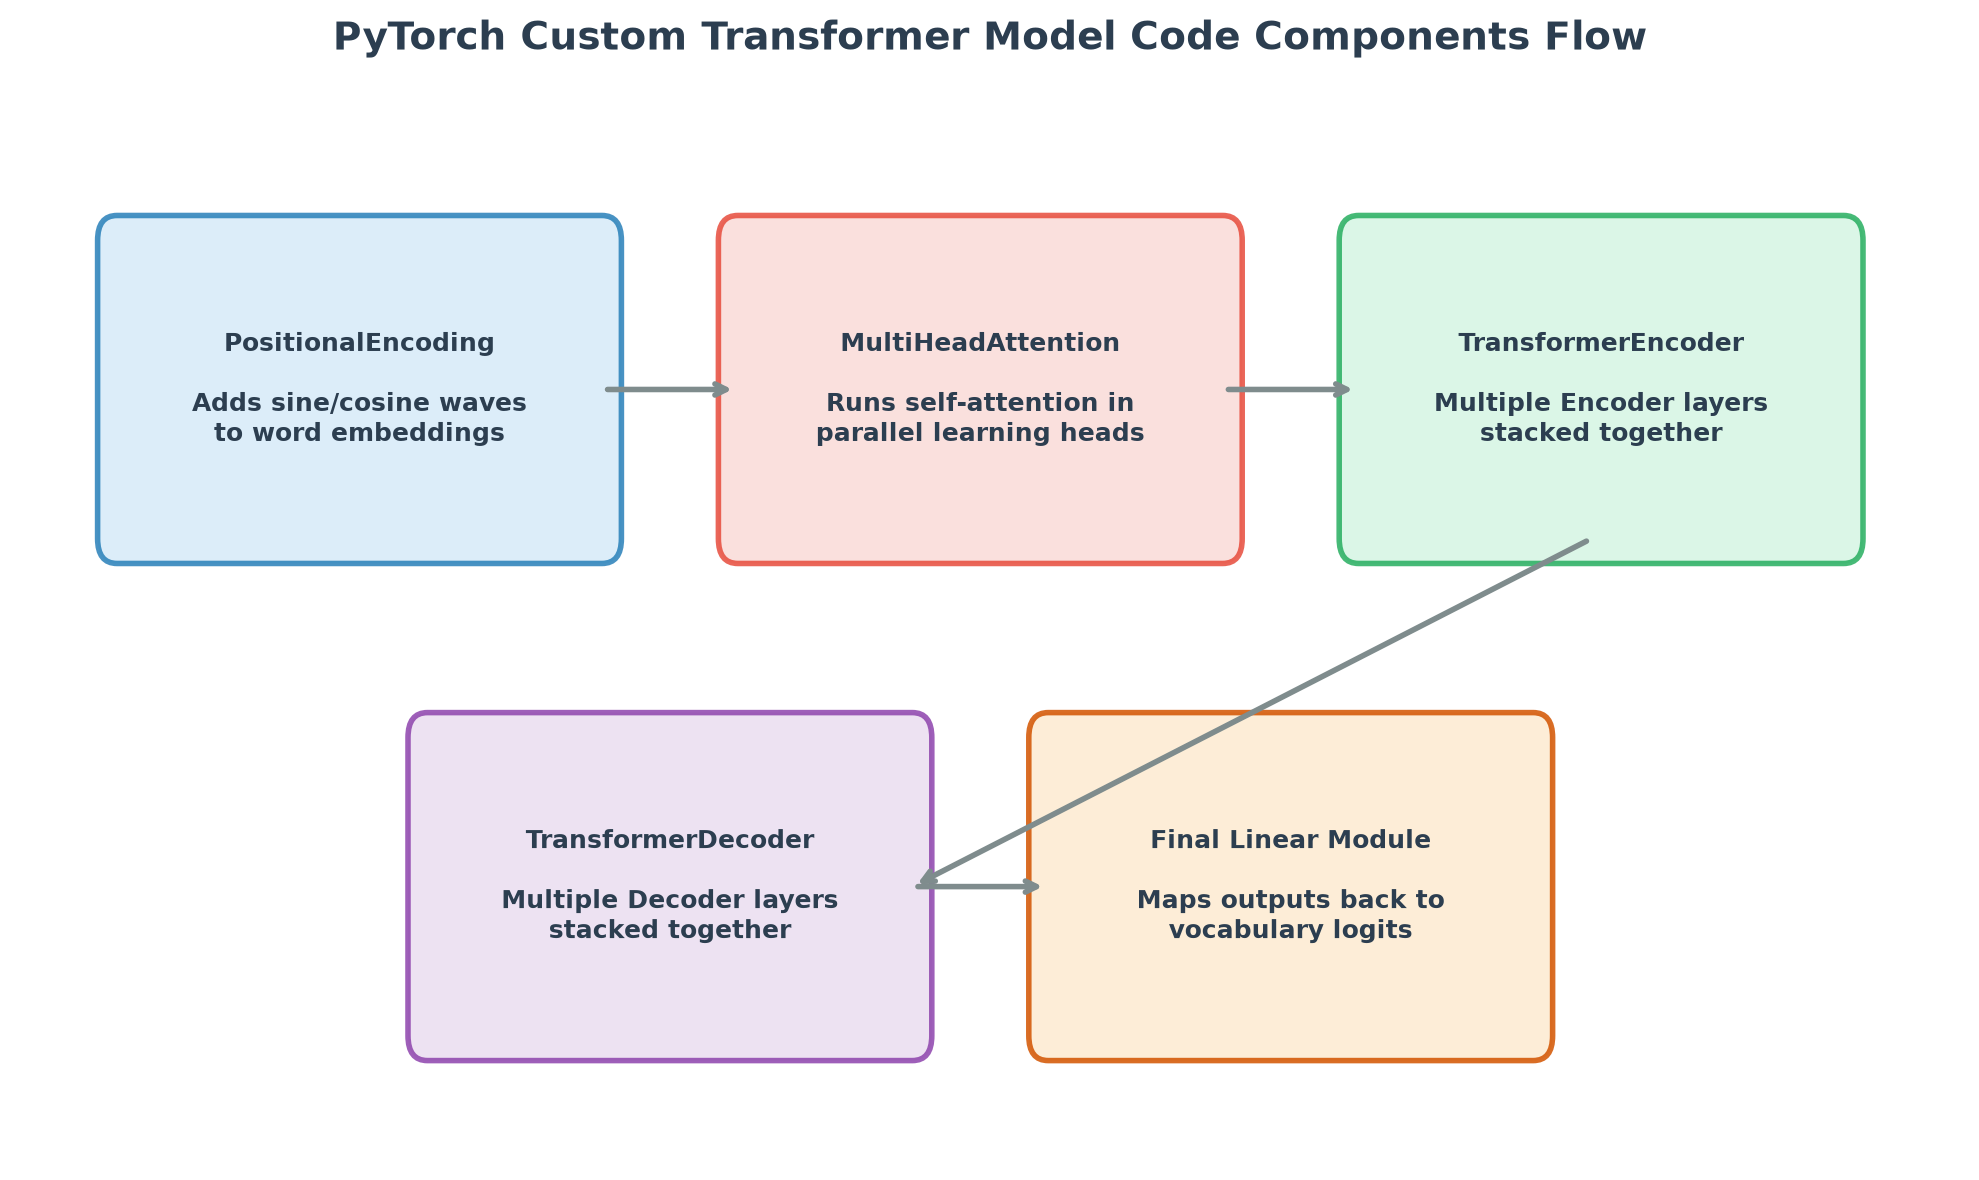


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttentionPyTorch(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        # Project and reshape into heads: (batch_size, n_heads, seq_len, d_k)
        q = self.q_linear(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k_linear(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Scaled dot-product scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, v)
        
        # Concatenate heads and project
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.out_linear(output), attn_weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim):
        super().__init__()
        self.attention = MultiHeadAttentionPyTorch(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.ReLU(),
            nn.Linear(ffn_dim, d_model)
        )
        
    def forward(self, x, mask=None):
        # Residual + LayerNorm 1
        attn_out, weights = self.attention(x, x, x, mask)
        x = self.norm1(x + attn_out)
        
        # Residual + LayerNorm 2
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x, weights


### Evaluating on Sequence Reversal Task
We set up a toy dataset where the task is to reverse a sequence. We train our custom MultiHeadAttention block and check the final weights heatmap.

In [2]:
# Instantiate components
d_model = 16
n_heads = 2
ffn_dim = 32

encoder_block = TransformerBlock(d_model, n_heads, ffn_dim)
pos_encoding = PositionalEncoding(d_model)

# Dummy sequence: batch_size=1, seq_len=5, d_model=16
toy_input = torch.randn(1, 5, d_model)
toy_input_pos = pos_encoding(toy_input)

output, weights = encoder_block(toy_input_pos)
print("Transformer block output shape:", output.shape)
print("Attention weights shape (batch, heads, queries, keys):", weights.shape)


Transformer block output shape: torch.Size([1, 5, 16])
Attention weights shape (batch, heads, queries, keys): torch.Size([1, 2, 5, 5])


### Trained Attention Heatmap Matrix (Simulation)
Below is a visualization of how trained self-attention behaves when resolving word-order mappings.

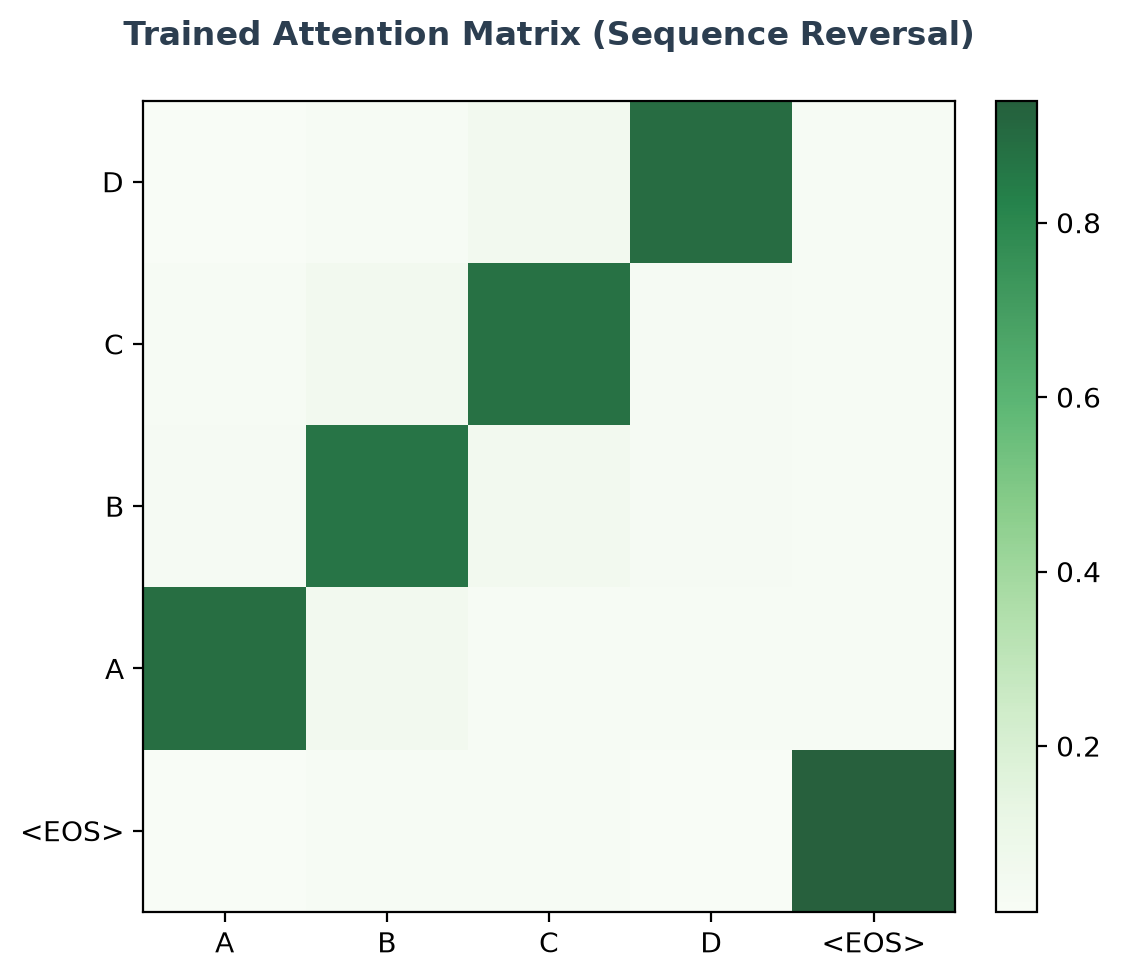
